In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Cargar Datos

In [2]:
path_ventas = "datos/BD2526_oct_mar_ventasxfacturas(con_zonas).csv"
ventas = pd.read_csv(path_ventas)
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_67714/3380775179.py:2: DtypeWarning: Columns (0: Cod Canal Comercial) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Kilos Nc', 'Monto Nc',
       'Factura Venta', 'Factura Kilos', 'Kilo Real', 'Monto Real', 'Precio',
       'Archivo', 'Hoja', 'Zona'],
      dtype='str')

In [4]:
# Filtrar canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 4043922


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [5]:
# Filtrar a solo segundo semestre de 2025
ventas = ventas[ventas["Año"] == 2025]
ventas = ventas[ventas["Mes"] >= 7]
print("Ventas después de filtrar fechas - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar fechas - Filas: 2081292


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [6]:
path_productos = "datos/Maestro Productos.xlsx"
productos = pd.read_excel(path_productos, header=2)
productos.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [7]:
productos.columns

Index(['Material', 'Texto breve de material', 'Material - COD SKU',
       'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
       'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
       'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
       'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
       'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
       'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
       'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
       'Descripción'],
      dtype='str')

In [8]:
# Index(['Material', 'Texto breve de material', 'Material - COD SKU',
#        'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
#        'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
#        'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
#        'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
#        'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
#        'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
#        'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
#        'Descripción'],
#       dtype='str')

In [9]:
# Agregar a ventas información de producto según SKU
# Agregamos la denominación asociada a Gr. Empaq y la Denominación asociada a Gr. Carga
ventas = ventas.merge(
    productos[["Material", "Denom..2", "Denominación.2"]],
    left_on="Cod SKU",
    right_on="Material",
    how="left",
)
# Cambiar nombre de columnas para evitar confusión
ventas.rename(columns={"Denom..2": "Empaque", "Denominación.2": "Carga"}, inplace=True)
ventas.head()

,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona,Material,Empaque,Carga
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,6776,ENVASADO,ENVASES
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,399,GRANEL,PIEZAS PESO ESTÁNDAR
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,8777,ENVASADO,VIENESAS
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2,3149,ENVASADO,PATES
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO,8508,GRANEL,PIEZAS PESO ESTÁNDAR


# 1. Calcular variables por cliente

In [10]:
# Armar dataframe de clientes al que le iremos agregando columnas de las variables a usar para clusterizar/segmentar
segmentacion_clientes = ventas[["Cod Cliente"]].drop_duplicates().reset_index(drop=True)
print("Número de clientes únicos:", segmentacion_clientes.shape[0])
segmentacion_clientes.head()

Número de clientes únicos: 41517


,Cod Cliente
0,1199536
1,1178409
2,1096778
3,1151218
4,1000127


## 1.1 Tamaño de compra

In [11]:
# Agregamos venta neta total por cliente
venta_neta_cliente = ventas.groupby("Cod Cliente")["Monto Real"].sum().reset_index()
segmentacion_clientes = segmentacion_clientes.merge(venta_neta_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,Monto Real
0,1199536,444016
1,1178409,1308027
2,1096778,4031626
3,1151218,1540719
4,1000127,120615


In [12]:
# Agregamos número de facturas por cliente
num_facturas_cliente = ventas.groupby("Cod Cliente")["N° Factura"].nunique().reset_index().rename(columns={"Monto Real": "n_facturas"})
segmentacion_clientes = segmentacion_clientes.merge(num_facturas_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.rename(columns={"Monto Real": "venta_total_clp", "N° Factura": "n_facturas"}, inplace=True)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas
0,1199536,444016,16
1,1178409,1308027,13
2,1096778,4031626,15
3,1151218,1540719,18
4,1000127,120615,4


In [13]:
# Agregamos ticket promedio por cliente
segmentacion_clientes["ticket_promedio"] = segmentacion_clientes["venta_total_clp"] / segmentacion_clientes["n_facturas"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio
0,1199536,444016,16,27751.000000
1,1178409,1308027,13,100617.461538
2,1096778,4031626,15,268775.066667
3,1151218,1540719,18,85595.500000
4,1000127,120615,4,30153.750000


In [14]:
# Agregamos desviación estandar del ticket por cliente
ticket_desv_std_cliente = ventas.groupby("Cod Cliente")["Monto Real"].std().reset_index()
ticket_desv_std_cliente.rename(columns={"Monto Real": "ticket_desv_std"}, inplace=True)
segmentacion_clientes = segmentacion_clientes.merge(ticket_desv_std_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std
0,1199536,444016,16,27751.000000,5040.351940
1,1178409,1308027,13,100617.461538,7271.205400
2,1096778,4031626,15,268775.066667,20024.773225
3,1151218,1540719,18,85595.500000,13331.283164
4,1000127,120615,4,30153.750000,9503.757257


# 1.2 Frecuencia y recencia de compra

In [15]:
# Días promedio entre compras por cliente
# Fecha está en formato 20251002
ventas["Fecha Factura"] = pd.to_datetime(ventas["Fecha Factura"], format="%Y%m%d")

compras_por_dia = (
    ventas.groupby(["Cod Cliente", "Fecha Factura"], as_index=False)
    .size()
)

dias_entre_compras = (
    compras_por_dia
    .sort_values(["Cod Cliente", "Fecha Factura"])
    .groupby("Cod Cliente")["Fecha Factura"]
    .apply(lambda x: x.diff().dt.days.mean())
    .reset_index(name="dias_entre_compras")
)

segmentacion_clientes = segmentacion_clientes.merge(
    dias_entre_compras,
    on="Cod Cliente",
    how="left"
)

segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras
0,1199536,444016,16,27751.000000,5040.351940,12.833333
1,1178409,1308027,13,100617.461538,7271.205400,8.600000
2,1096778,4031626,15,268775.066667,20024.773225,6.428571
3,1151218,1540719,18,85595.500000,13331.283164,6.000000
4,1000127,120615,4,30153.750000,9503.757257,21.000000


In [16]:
# Fecha de referencia para medir recencia
fecha_referencia = ventas["Fecha Factura"].max() + pd.Timedelta(days=1)

# Última compra por cliente
recencia_clientes = (
    ventas.groupby("Cod Cliente")["Fecha Factura"]
    .max()
    .reset_index(name="ultima_compra")
)

# Recencia en días
recencia_clientes["recencia"] = (
    fecha_referencia - recencia_clientes["ultima_compra"]
).dt.days

# Merge con tu tabla de segmentación
segmentacion_clientes = segmentacion_clientes.merge(
    recencia_clientes[["Cod Cliente", "recencia"]],
    on="Cod Cliente",
    how="left"
)

segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29


# 1.3 Composición de compra

In [17]:
# Cantidad de SKUs distintos comprados por cliente
skus_distintos_cliente = ventas.groupby("Cod Cliente")["Cod SKU"].nunique().reset_index()
skus_distintos_cliente.rename(columns={"Cod SKU": "skus_distintos"}, inplace=True)
segmentacion_clientes = segmentacion_clientes.merge(skus_distintos_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2


In [18]:
# Share de cada marca por cliente en porcentaje del monto total comprado por el cliente
marcas = ["LA PREFERIDA", "SAN JORGE", "WINTER", "Los Nogales"]
for marca in marcas:
    share_marca_cliente = ventas[ventas["Nombre Marca"] == marca].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_marca_cliente.rename(columns={"Monto Real": f"share_marca_{marca}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_marca_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_marca_{marca}"] = segmentacion_clientes[f"share_marca_{marca}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,share_marca_WINTER,share_marca_Los Nogales
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,0.171901,0.196934
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,0.207750,0.116198
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,0.147966,0.044791
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,0.209845,0.406312
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,0.067529,0.932471


In [19]:
# HHI de marcas por cliente - medida de concentración de compra en una marca (entre más cerca a 1, más concentrado en una marca)
segmentacion_clientes["hhi_marcas"] = 0
for marca in marcas:
    segmentacion_clientes["hhi_marcas"] += (segmentacion_clientes[f"share_marca_{marca}"] ** 2)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,share_marca_WINTER,share_marca_Los Nogales,hhi_marcas
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,0.171901,0.196934,0.360478
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,0.207750,0.116198,0.316715
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,0.147966,0.044791,0.548200
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,0.209845,0.406312,0.279521
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,0.067529,0.932471,NaN


In [20]:
# Share de cada familia por cliente en porcentaje del monto total comprado por el cliente
familias = ventas["Nombre Familia"].unique()
for familia in familias:
    share_familia_cliente = ventas[ventas["Nombre Familia"] == familia].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_familia_cliente.rename(columns={"Monto Real": f"share_familia_{familia}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_familia_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_familia_{familia}"] = segmentacion_clientes[f"share_familia_{familia}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_ARROLLADOS,share_familia_HAMBURGUESAS,share_familia_OTROS COMERCIALIZADORA,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,...,NaN,0.116870,NaN,0.146724,NaN,NaN,NaN,NaN,NaN,NaN
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,...,0.054732,NaN,NaN,NaN,NaN,0.076786,NaN,0.028169,NaN,NaN
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,...,NaN,0.057233,NaN,NaN,NaN,NaN,0.084115,NaN,NaN,NaN
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,...,NaN,0.086486,NaN,NaN,NaN,NaN,0.010491,0.007972,NaN,NaN
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# HHI de familias por cliente - medida de concentración de compra en una familia (entre más cerca a 1, más concentrado en una familia)
segmentacion_clientes["hhi_familias"] = 0
for familia in familias:
    segmentacion_clientes["hhi_familias"] += (segmentacion_clientes[f"share_familia_{familia}"] ** 2)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_HAMBURGUESAS,share_familia_OTROS COMERCIALIZADORA,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,hhi_familias
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,...,0.116870,NaN,0.146724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,...,NaN,NaN,NaN,NaN,0.076786,NaN,0.028169,NaN,NaN,NaN
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,...,0.057233,NaN,NaN,NaN,NaN,0.084115,NaN,NaN,NaN,NaN
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,...,0.086486,NaN,NaN,NaN,NaN,0.010491,0.007972,NaN,NaN,NaN
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Share de cada empaque por cliente en porcentaje del monto total comprado por el cliente
empaques = ventas["Empaque"].unique()
for empaque in empaques:
    share_empaque_cliente = ventas[ventas["Empaque"] == empaque].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_empaque_cliente.rename(columns={"Monto Real": f"share_empaque_{empaque}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_empaque_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_empaque_{empaque}"] = segmentacion_clientes[f"share_empaque_{empaque}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,hhi_familias,share_empaque_ENVASADO,share_empaque_GRANEL
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,...,0.146724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.771310,0.228690
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,...,NaN,NaN,0.076786,NaN,0.028169,NaN,NaN,NaN,0.291423,0.708577
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,...,NaN,NaN,NaN,0.084115,NaN,NaN,NaN,NaN,0.314258,0.685742
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,...,NaN,NaN,NaN,0.010491,0.007972,NaN,NaN,NaN,0.715863,0.284137
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN


In [23]:
# Share de cada carga por cliente en porcentaje del monto total comprado por el cliente
cargas = ventas["Carga"].unique()
for carga in cargas:
    share_carga_cliente = ventas[ventas["Carga"] == carga].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_carga_cliente.rename(columns={"Monto Real": f"share__carga_{carga}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_carga_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share__carga_{carga}"] = segmentacion_clientes[f"share__carga_{carga}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share__carga_PIEZAS PESO ESTÁNDAR,share__carga_VIENESAS,share__carga_PATES,share__carga_LAMINADOS,share__carga_PESO VARIABLE,share__carga_CONGELADOS,share__carga_FRESH PACK,share__carga_PARRILLEROS,share__carga_POUCH,share__carga_OTROS
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,...,0.272355,0.212373,0.054744,NaN,NaN,0.263594,NaN,NaN,NaN,NaN
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,...,0.175543,0.056524,0.075708,0.149620,0.440611,NaN,NaN,NaN,NaN,NaN
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,...,0.090733,0.043944,0.078204,0.106662,0.539110,0.057233,NaN,0.084115,NaN,NaN
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,...,0.144784,0.095947,0.045309,0.392094,0.124878,0.086486,0.014293,0.010491,NaN,0.028998
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,...,NaN,0.067529,NaN,0.932471,NaN,NaN,NaN,NaN,NaN,NaN


## 1.4 Categóricas del Cliente

In [24]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

,Zona,Distrito,CodJV,CodSup,CodVend,NombreVendedor,Canal,SubCanal,CodCliente Padre,Cliente Padre,...,MA,MI,JU,VI,SA,Frecuencia,Tratamiento,CodPago,DesPago,Estado
0,SANTIAGO,SANTIAGO CENTRO COSTA,854,854,1084869,ALEXIS PEREZ MUÑOZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,1.0,0,1.0,Cliente,C005,FIRMA 7 DIAS,1
1,SUR 1,RANCAGUA,481,481,482,JUAN FARIAS PEREZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,0.0,0,0.5,Cliente,C000,EFECTIVO - CHEQUE AL DIA,1
2,SUR 2,CONCEPCION SUR,1178566,1178566,1084857,ALEX RIOS CUEVAS,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.5,0.0,0,0.5,Cliente,C017,EFECTIVO,1
3,SUR 1,TALCA,581,581,1160963,RODRIGO AVENDAÑO HERNANDEZ,COBERTURA,COBERTURA,0,-,...,0.0,1.0,0.0,0.0,0,1.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1
4,NORTE 2,VIÑA COSTA,1216438,1216438,1206012,PAULO RUZ BILBAO,COBERTURA,COBERTURA,0,-,...,1.0,0.0,0.0,1.0,0,2.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1


In [25]:
clientes.columns

Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
       'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
       'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
       'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
       'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
       'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
       'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
      dtype='str')

In [26]:
# COLS: 
# Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
    # 'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
    # 'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
    # 'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
    # 'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
    # 'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
    # 'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
    # dtype='str')

In [27]:
# Agregar Zona, Distrito, Comuna, Canal, Subcanal, TipoNeg a segmentacion_clientes
segmentacion_clientes = segmentacion_clientes.merge(clientes[["CodCliente", "Zona", "Distrito", "Comuna", "Canal", "SubCanal", "TipoNeg"]], left_on="Cod Cliente", right_on="CodCliente", how="left")
segmentacion_clientes.drop(columns=["CodCliente"], inplace=True)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share__carga_FRESH PACK,share__carga_PARRILLEROS,share__carga_POUCH,share__carga_OTROS,Zona,Distrito,Comuna,Canal,SubCanal,TipoNeg
0,1199536,444016,16,27751.000000,5040.351940,12.833333,15,14,0.099990,0.531175,...,NaN,NaN,NaN,NaN,SUR 1,TALCA,LINARES,COBERTURA,COBERTURA,AL
1,1178409,1308027,13,100617.461538,7271.205400,8.600000,5,19,0.212467,0.463585,...,NaN,NaN,NaN,NaN,NORTE 2,VIÑA INTERIOR,QUILLOTA,COBERTURA,COBERTURA,AL
2,1096778,4031626,15,268775.066667,20024.773225,6.428571,2,25,0.718645,0.088598,...,NaN,0.084115,NaN,NaN,SANTIAGO,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,VOLUMEN COBERTURA,AL
3,1151218,1540719,18,85595.500000,13331.283164,6.000000,2,30,0.238411,0.116433,...,0.014293,0.010491,NaN,0.028998,SANTIAGO,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,COBERTURA,AL
4,1000127,120615,4,30153.750000,9503.757257,21.000000,29,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NORTE 2,SAN FELIPE,LOS ANDES,COBERTURA,COBERTURA,AL


# 2. Calcular clusters

In [28]:
# Variables disponibles
vars_disponibles = segmentacion_clientes.columns.tolist()
print(f"Variables disponibles para segmentación: {len(vars_disponibles)}")
for var in vars_disponibles:
    print(var)

Variables disponibles para segmentación: 53
Cod Cliente
venta_total_clp
n_facturas
ticket_promedio
ticket_desv_std
dias_entre_compras
recencia
skus_distintos
share_marca_LA PREFERIDA
share_marca_SAN JORGE
share_marca_WINTER
share_marca_Los Nogales
hhi_marcas
share_familia_LACTEOS
share_familia_MORTADELAS
share_familia_VIENESAS
share_familia_PATE
share_familia_QUESOS
share_familia_HORTALIZAS
share_familia_JAMON G1
share_familia_SNACKS
share_familia_SALAMES
share_familia_JAMON G2
share_familia_ARROLLADOS
share_familia_HAMBURGUESAS
share_familia_OTROS COMERCIALIZADORA
share_familia_CARNES
share_familia_TIPICOS
share_familia_FIAMBRES
share_familia_PARRILLEROS
share_familia_TOCINOS
share_familia_EMPANIZADOS
share_familia_SECOS
hhi_familias
share_empaque_ENVASADO
share_empaque_GRANEL
share__carga_ENVASES
share__carga_PIEZAS PESO ESTÁNDAR
share__carga_VIENESAS
share__carga_PATES
share__carga_LAMINADOS
share__carga_PESO VARIABLE
share__carga_CONGELADOS
share__carga_FRESH PACK
share__carga_PARR

In [29]:
#Sacar Columnas que no aportan a segmentación, redundantes
columnas_a_eliminar = [
    "share_marca_WINTER",
    "share_familia_SECOS",
    "share_empaque_ENVASADO",
    "share__carga_OTROS",
]

data_clientes = segmentacion_clientes.drop(columns=columnas_a_eliminar)

In [30]:
columnas_clustering = [
    # "Zona",
    # "Comuna",
    # "Canal",
    # "SubCanal",
    # "TipoNeg",
    "Cod Cliente",
    # "venta_total_clp",
    "ticket_promedio",
    "n_facturas",
    # "ticket_desv_std",
    #"dias_entre_compras",
    "recencia",
    # "skus_distintos",
]
data_clientes = segmentacion_clientes[columnas_clustering]

In [31]:
data_clientes.head()

,Cod Cliente,ticket_promedio,n_facturas,recencia
0,1199536,27751.000000,16,15
1,1178409,100617.461538,13,5
2,1096778,268775.066667,15,2
3,1151218,85595.500000,18,2
4,1000127,30153.750000,4,29


In [32]:
from sklearn.preprocessing import StandardScaler, RobustScaler

cols = ["ticket_promedio", "n_facturas", "recencia"]
data_clientes = data_clientes[np.logical_and.reduce([data_clientes[c].between(data_clientes[c].quantile(0.01), data_clientes[c].quantile(0.99)) for c in cols])]

features = pd.get_dummies(data_clientes.drop(columns=["Cod Cliente"], errors="ignore"),
                          columns=data_clientes.select_dtypes(include=["object", "category"]).columns,
                          dummy_na=False).fillna(0)

# Preparar variables para clustering
# features = pd.get_dummies(
#     data_clientes.drop(columns=["Cod Cliente"], errors="ignore"),
#     columns=data_clientes.select_dtypes(include=["object", "category"]).columns,
#     dummy_na=False,
# )
# features = features.fillna(0)
# cols = ["ticket_promedio", "n_facturas", "recencia"]
#features = features[np.logical_and.reduce([features[c].between(features[c].quantile(0.01), features[c].quantile(0.99)) for c in cols])]

# Escalar datos
#scaler = StandardScaler()
scaler = RobustScaler()
data_scaled = scaler.fit_transform(features)

# Reducción de dimensionalidad con UMAP
# import umap
# umap_reducer = umap.UMAP(n_components=10, random_state=42)
# data_umap = umap_reducer.fit_transform(data_scaled)

In [33]:
# Clustering con HDBSCAN
# clusterer = hdbscan.HDBSCAN(min_cluster_size=250, min_samples=50)
# data_clientes["cluster"] = clusterer.fit_predict(data_umap)
# data_clientes.head()

In [34]:
# Cluster con KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=8, random_state=42)
data_clientes["cluster_kmeans"] = kmeans.fit_predict(data_scaled)
data_clientes.head()

,Cod Cliente,ticket_promedio,n_facturas,recencia,cluster_kmeans
0,1199536,27751.000000,16,15,5
1,1178409,100617.461538,13,5,6
2,1096778,268775.066667,15,2,2
3,1151218,85595.500000,18,2,6
4,1000127,30153.750000,4,29,1


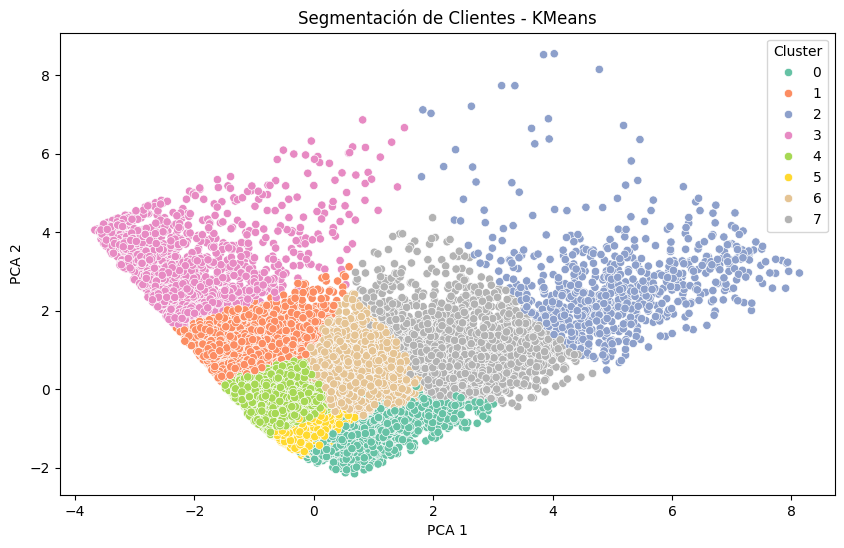

In [35]:
# Graficar clusters en 2D usando PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=data_clientes["cluster_kmeans"], palette="Set2", legend="full")
plt.title("Segmentación de Clientes - KMeans")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()

In [36]:
# Graficar segmentacion en 3D usando las 3 variables del clustering
# Si recalculas cluster_kmeans mas abajo, vuelve a ejecutar esta celda al final.
import plotly.express as px

cols_segmentacion = ["ticket_promedio", "n_facturas", "recencia"]
plot_3d = data_clientes[cols_segmentacion].copy()

faltantes = [col for col in cols_segmentacion if col not in plot_3d.columns]
if faltantes:
    raise ValueError(f"Faltan columnas para el grafico 3D: {faltantes}")

plot_3d["cluster_kmeans"] = data_clientes["cluster_kmeans"].astype(str)

if "Cod Cliente" in data_clientes.columns:
    plot_3d["Cod Cliente"] = data_clientes["Cod Cliente"].values

max_puntos = 15000
if len(plot_3d) > max_puntos:
    plot_3d_plot = plot_3d.sample(max_puntos, random_state=42).copy()
    print(f"Mostrando una muestra de {max_puntos:,} clientes sobre {len(plot_3d):,} para mantener el grafico fluido.")
else:
    plot_3d_plot = plot_3d.copy()

hover_data = {}
if "Cod Cliente" in plot_3d_plot.columns:
    hover_data["Cod Cliente"] = True

fig = px.scatter_3d(
    plot_3d_plot,
    x="ticket_promedio",
    y="n_facturas",
    z="recencia",
    color="cluster_kmeans",
    opacity=0.7,
    hover_data=hover_data,
    title="Segmentacion de clientes en 3D (variables originales)",
)

fig.update_traces(marker=dict(size=3))

if "kmeans" in globals() and hasattr(kmeans, "cluster_centers_"):
    centroides_df = pd.DataFrame(
        scaler.inverse_transform(kmeans.cluster_centers_),
        columns=features.columns,
    )
    faltantes_centroides = [col for col in cols_segmentacion if col not in centroides_df.columns]
    if not faltantes_centroides:
        fig.add_scatter3d(
            x=centroides_df["ticket_promedio"],
            y=centroides_df["n_facturas"],
            z=centroides_df["recencia"],
            mode="markers",
            marker=dict(size=8, color="black", symbol="diamond"),
            name="Centroides",
        )

fig.update_layout(
    height=750,
    legend_title_text="Cluster",
    scene=dict(
        xaxis_title="ticket_promedio",
        yaxis_title="n_facturas",
        zaxis_title="recencia",
    ),
)

fig.show()


Mostrando una muestra de 15,000 clientes sobre 40,002 para mantener el grafico fluido.


In [37]:
nombre_archivo = "grafico_segmentacion_3d.html"
fig.write_html(nombre_archivo, full_html=True, include_plotlyjs=True)
print(f"Grafico guardado en: {nombre_archivo}")

Grafico guardado en: grafico_segmentacion_3d.html


Calculando silhouette sobre una muestra de 15000 clientes
k=2: silhouette=0.4925 | clusters efectivos=2
k=3: silhouette=0.4455 | clusters efectivos=3
k=4: silhouette=0.3272 | clusters efectivos=4
k=5: silhouette=0.3313 | clusters efectivos=5
k=6: silhouette=0.3166 | clusters efectivos=6
k=7: silhouette=0.3142 | clusters efectivos=7
k=8: silhouette=0.2946 | clusters efectivos=8
k=9: silhouette=0.2907 | clusters efectivos=9
k=10: silhouette=0.2864 | clusters efectivos=10
Mejor numero de clusters segun silhouette: 2


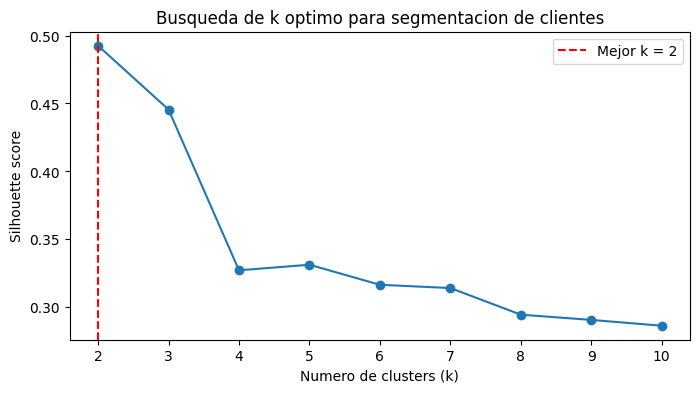

,k,silhouette_score,clusters_efectivos
0,2,0.492505,2
1,3,0.445508,3
2,4,0.327223,4
3,5,0.331327,5
4,6,0.316567,6
5,7,0.314169,7
6,8,0.294568,8
7,9,0.290712,9
8,10,0.286435,10


In [38]:
# Buscar k óptimo para KMeans con silhouette score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

parametros_kmeans = {
    "random_state": 42,
    "n_init": 10,
}

k_min = 2
k_max = min(10, data_scaled.shape[0] - 1)
if k_max < k_min:
    raise ValueError("No hay suficientes clientes para evaluar múltiples clusters.")

rango_clusters = range(k_min, k_max + 1)
# Baja este valor si el cálculo tarda demasiado en tu notebook.
tamano_muestra_silhouette = min(15000, data_scaled.shape[0])
print(f"Calculando silhouette sobre una muestra de {tamano_muestra_silhouette} clientes")

resultados_silhouette = []
indices_totales = np.arange(data_scaled.shape[0])

for k in rango_clusters:
    modelo_tmp = KMeans(
        n_clusters=k,
        **parametros_kmeans,
    )
    labels_tmp = modelo_tmp.fit_predict(data_scaled)
    labels_unicos = np.unique(labels_tmp)
    n_clusters_efectivos = len(labels_unicos)

    if n_clusters_efectivos < 2:
        resultados_silhouette.append(
            {
                "k": k,
                "silhouette_score": np.nan,
                "clusters_efectivos": n_clusters_efectivos,
            }
        )
        print(f"k={k}: omitido, KMeans produjo {n_clusters_efectivos} cluster efectivo")
        continue

    if tamano_muestra_silhouette >= data_scaled.shape[0]:
        indices_eval = indices_totales
    else:
        rng = np.random.default_rng(42)
        indices_obligatorios = np.array(
            [
                rng.choice(np.flatnonzero(labels_tmp == label))
                for label in labels_unicos
            ],
            dtype=int,
        )
        restantes = tamano_muestra_silhouette - len(indices_obligatorios)

        if restantes > 0:
            universo = np.setdiff1d(indices_totales, indices_obligatorios, assume_unique=False)
            indices_extra = rng.choice(
                universo,
                size=min(restantes, len(universo)),
                replace=False,
            )
            indices_eval = np.concatenate([indices_obligatorios, indices_extra])
        else:
            indices_eval = indices_obligatorios[:tamano_muestra_silhouette]

        rng.shuffle(indices_eval)

    labels_eval = labels_tmp[indices_eval]
    if np.unique(labels_eval).size < 2:
        resultados_silhouette.append(
            {
                "k": k,
                "silhouette_score": np.nan,
                "clusters_efectivos": n_clusters_efectivos,
            }
        )
        print(f"k={k}: omitido, la muestra de evaluación quedó con un solo cluster")
        continue

    score_tmp = silhouette_score(
        data_scaled[indices_eval],
        labels_eval,
    )
    resultados_silhouette.append(
        {
            "k": k,
            "silhouette_score": score_tmp,
            "clusters_efectivos": n_clusters_efectivos,
        }
    )
    print(f"k={k}: silhouette={score_tmp:.4f} | clusters efectivos={n_clusters_efectivos}")

resultados_silhouette = pd.DataFrame(resultados_silhouette)
resultados_validos = resultados_silhouette.dropna(subset=["silhouette_score"]).copy()
if resultados_validos.empty:
    raise ValueError("No fue posible calcular silhouette para ningun k. Revisa si hay muy poca variabilidad en los datos.")

num_clusters = int(
    resultados_validos.loc[
        resultados_validos["silhouette_score"].idxmax(),
        "k",
    ]
)
print(f"Mejor numero de clusters segun silhouette: {num_clusters}")

plt.figure(figsize=(8, 4))
plt.plot(
    resultados_validos["k"],
    resultados_validos["silhouette_score"],
    marker="o",
)
plt.axvline(num_clusters, color="red", linestyle="--", label=f"Mejor k = {num_clusters}")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Busqueda de k optimo para segmentacion de clientes")
plt.legend()
plt.show()

kmeans = KMeans(
    n_clusters=num_clusters,
    **parametros_kmeans,
)
data_clientes["cluster_kmeans"] = kmeans.fit_predict(data_scaled)

resultados_silhouette


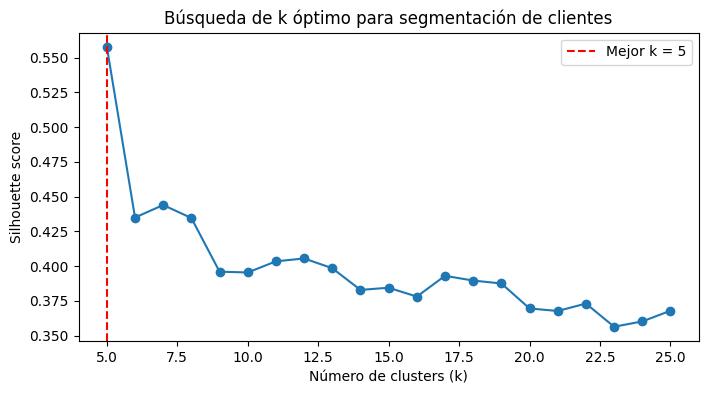

In [39]:
#data_clientes.to_csv("segmentacion_clientes_comportamiento.csv", index=False)

In [40]:
data_clientes["cluster_kmeans"].value_counts()

cluster_kmeans
0    34972
1     5030
Name: count, dtype: int64